In [93]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path.cwd().parent
import pandas as pd
vol_csv = pd.read_csv(BASE_DIR / "Tree_Modelling" / "VOLUME_DATASET.csv")
print(vol_csv.head())

   Unnamed: 0  OBJECTID          X          Y           LATIN_NAME  \
0         130  26609482  358778.42  173631.65       Betula pendula   
1         131  26609483  358769.66  173620.75        Betula utilis   
2         391  26609746  359249.26  173476.59  Acer platanoides cv   
3         392  26609747  359262.25  173477.53  Acer platanoides cv   
4         393  26609748  359276.98  173478.16  Acer platanoides cv   

    COMMON_NAME       FULL_COMMON_NAME         TREE_SPECIES   DBH tree_group  \
0  Silver Birch           Silver birch       Betula pendula  0.06  deciduous   
1         Birch        Himalayan birch        Betula utilis  0.32  deciduous   
2         Maple  Norway maple cultivar  Acer platanoides cv  0.50  deciduous   
3         Maple  Norway maple cultivar  Acer platanoides cv  0.40  deciduous   
4         Maple  Norway maple cultivar  Acer platanoides cv  0.40  deciduous   

   CROWN_AREA_COMPLETE  CROWN_VOLUME  
0             3.593897      8.579590  
1            10.0000

In [94]:
df_sensor = pd.read_csv(BASE_DIR / "site_outputs" / "site_463.csv")
print(df_sensor)

      SITE_ID   EASTING  NORTHING   NOX        DATE_TIME_STR
0         463  362926.0  175590.0   9.0  2023-01-01 01:00:00
1         463  362926.0  175590.0  12.0  2023-01-01 02:00:00
2         463  362926.0  175590.0   6.0  2023-01-01 03:00:00
3         463  362926.0  175590.0   7.0  2023-01-01 04:00:00
4         463  362926.0  175590.0   6.0  2023-01-01 05:00:00
...       ...       ...       ...   ...                  ...
8754      463  362926.0  175590.0  30.0  2023-12-31 19:00:00
8755      463  362926.0  175590.0  17.0  2023-12-31 20:00:00
8756      463  362926.0  175590.0  17.0  2023-12-31 21:00:00
8757      463  362926.0  175590.0  17.0  2023-12-31 22:00:00
8758      463  362926.0  175590.0  13.0  2023-12-31 23:00:00

[8759 rows x 5 columns]


In [95]:
import numpy as np

# Define your sensor location and the radius
SENSOR_X = 362926  # Replace with your sensor's Easting
SENSOR_Y = 175590  # Replace with your sensor's Northing
radius = 300.0       # meters

# Calculate the Euclidean distance for all rows simultaneously (vectorized for speed)
distances = np.sqrt((vol_csv['X'] - SENSOR_X)**2 + (vol_csv['Y'] - SENSOR_Y)**2)

# Filter the dataframe to only include trees within the radius
nearby_trees = vol_csv[distances <= radius].copy()

# Add the calculated distance as a new column
nearby_trees['DISTANCE_TO_SENSOR'] = distances[distances <= radius]

print(f"Found {len(nearby_trees)} trees within {radius}m of the sensor.")
# print(nearby_trees.head())

nearby_trees.to_csv('SENSOR_ID_203.csv')

Found 112 trees within 300.0m of the sensor.


In [96]:
print(nearby_trees)

      Unnamed: 0  OBJECTID          X          Y                LATIN_NAME  \
93          3867  26613290  362930.22  175834.30        Fraxinus excelsior   
94          3868  26613291  362925.75  175831.44        Fraxinus excelsior   
95          3869  26613292  362919.06  175827.37            Sambucus nigra   
96          3870  26613293  362913.55  175824.40        Fraxinus excelsior   
97          3871  26613294  362898.67  175812.16        Fraxinus excelsior   
...          ...       ...        ...        ...                       ...   
1327       50745  26660651  363017.49  175520.66  Prunus - Species Unknown   
1328       50746  26660652  363015.95  175525.20   Malus - Species Unknown   
1329       50747  26660653  363019.38  175525.69  Prunus - Species Unknown   
1330       50748  26660654  363020.26  175521.58   Malus - Species Unknown   
1331       50782  26660688  363027.46  175532.48   Salix - Species Unknown   

     COMMON_NAME     FULL_COMMON_NAME              TREE_SPECIES

In [97]:
df_wind = pd.read_csv('../Wind Data/wind_2023_interpolated.csv')
wind_subset = df_wind[['mean_wind_speed', 'mean_wind_dir']]

print(df_wind.columns)
print(df_wind.head())
print(df_wind.shape)

df_wind["ob_end_time"] = pd.to_datetime(df_wind["ob_end_time"], errors="coerce")

wind_2023 = df_wind[
    (df_wind["ob_end_time"] >= "2023-01-01") &
    (df_wind["ob_end_time"] < "2024-01-01")
].copy()

wind_2023 = wind_2023[[
    "ob_end_time",
    "mean_wind_speed",
    "mean_wind_dir"
]].copy()

wind_2023 = wind_2023.sort_values("ob_end_time").reset_index(drop=True)

Index(['ob_end_time', 'mean_wind_speed', 'mean_wind_dir', 'wind_to_dir',
       'wind_to_sector', 'theta_rad', 'wind_x', 'wind_y'],
      dtype='object')
                 ob_end_time  mean_wind_speed  mean_wind_dir  wind_to_dir  \
0  2023-01-01 00:00:00+00:00             11.0          210.0         30.0   
1  2023-01-01 01:00:00+00:00             11.0          210.0         30.0   
2  2023-01-01 02:00:00+00:00             10.0          210.0         30.0   
3  2023-01-01 03:00:00+00:00              9.0          200.0         20.0   
4  2023-01-01 04:00:00+00:00              8.0          190.0         10.0   

  wind_to_sector  theta_rad    wind_x    wind_y  
0             NE   0.523599  0.500000  0.866025  
1             NE   0.523599  0.500000  0.866025  
2             NE   0.523599  0.500000  0.866025  
3              N   0.349066  0.342020  0.939693  
4              N   0.174533  0.173648  0.984808  
(8760, 8)


## Sunlight and seasonality integration

This section calculates hourly sunlight and leaf multipliers, then applies them inside the geometric sink model.

In [98]:
# ============================================================
# Sunlight + seasonality multipliers for the selected sensor
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# Adjust only this path if needed
sun_path = Path('../sunrise and sunset data/bristol_sun_2023.csv')

sun = pd.read_csv(sun_path)

print(sun.shape)

# --- 1) Prepare hourly sensor timestamps ---
# The sensor dataset contains the hourly DATE_TIME used to align everything.
df_sensor["DATE_TIME_STR"] = pd.to_datetime(df_sensor["DATE_TIME_STR"], errors="coerce")
df_sensor = df_sensor.dropna(subset=["DATE_TIME_STR"]).copy()

# Clip to 2023 because this is the year covered by the sunlight/wind data.
df_sensor_2023 = df_sensor[
    (df_sensor["DATE_TIME_STR"] >= "2023-01-01") &
    (df_sensor["DATE_TIME_STR"] < "2024-01-01")
].copy()

df_sensor_2023["date"] = df_sensor_2023["DATE_TIME_STR"].dt.normalize()
df_sensor_2023["day_of_year"] = df_sensor_2023["DATE_TIME_STR"].dt.dayofyear
df_sensor_2023["month"] = df_sensor_2023["DATE_TIME_STR"].dt.month
df_sensor_2023["hour"] = df_sensor_2023["DATE_TIME_STR"].dt.hour

# --- 2) Prepare sunrise/sunset data ---
sun["date"] = pd.to_datetime(sun["date"], errors="coerce").dt.normalize()

sun["Sunrise_clean"] = (
    sun["Sunrise/Sunset Sunrise Sunrise"]
    .astype(str)
    .str.extract(r"(\d{1,2}:\d{2}\s*[ap]m)", expand=False)
    .str.upper()
)

sun["Sunset_clean"] = (
    sun["Sunrise/Sunset Sunset Sunset"]
    .astype(str)
    .str.extract(r"(\d{1,2}:\d{2}\s*[ap]m)", expand=False)
    .str.upper()
)

sun["sunrise_dt"] = pd.to_datetime(
    sun["date"].dt.strftime("%Y-%m-%d") + " " + sun["Sunrise_clean"],
    format="%Y-%m-%d %I:%M %p",
    errors="coerce"
)

sun["sunset_dt"] = pd.to_datetime(
    sun["date"].dt.strftime("%Y-%m-%d") + " " + sun["Sunset_clean"],
    format="%Y-%m-%d %I:%M %p",
    errors="coerce"
)

# --- 3) Daylight fraction per sensor hour ---
hourly_context = df_sensor_2023.merge(
    sun[["date", "sunrise_dt", "sunset_dt"]],
    on="date",
    how="left"
)

hourly_context["hour_start"] = hourly_context["DATE_TIME_STR"]
hourly_context["hour_end"] = hourly_context["DATE_TIME_STR"] + pd.Timedelta(hours=1)

def daylight_fraction(row):
    start = row["hour_start"]
    end = row["hour_end"]
    sunrise = row["sunrise_dt"]
    sunset = row["sunset_dt"]

    if pd.isna(sunrise) or pd.isna(sunset):
        return np.nan

    # Completely dark
    if end <= sunrise or start >= sunset:
        return 0.0

    # Fully daylight
    if start >= sunrise and end <= sunset:
        return 1.0

    # Partial daylight during sunrise hour
    if start < sunrise < end:
        return (end - sunrise).total_seconds() / 3600

    # Partial daylight during sunset hour
    if start < sunset < end:
        return (sunset - start).total_seconds() / 3600

    return 0.0

hourly_context["sun_multiplier"] = hourly_context.apply(daylight_fraction, axis=1)

# --- 4) Leaf seasonality setup for nearby trees ---
nearby_trees["COMMON_NAME"] = nearby_trees["COMMON_NAME"].astype(str).str.strip()

evergreens = {
    "Bay", "Box", "Cabbage Palm", "Cedar", "Chusan Palm", "Conifer", "Cypress", "Douglas Fir", "Eleagnus",
    "Eucalyptus", "Feijoa", "Fir", "Firethorn", "Hiba", "Hemlock", "Holly", "Juniper", "Laurel", "Monkey Puzzle",
    "Pine", "Pittosporum", "Redwood", "Scots Pine", "Spruce", "Strawberry Tree", "Wedding Cake Tree", "Yew"
}

leaf_periods = {
    "Lime": (4, 10), "Cherry": (4, 9), "Maple": (5, 10), "Ash": (5, 10),
    "Sycamore": (5, 10), "Plane": (5, 10), "Oak": (5, 11), "Silver Birch": (4, 9),
    "Hawthorn": (4, 10), "Apple": (5, 10), "Field Maple": (5, 10), "Horse Chestnut": (4, 9),
    "Alder": (4, 10), "Hornbeam": (4, 11), "Whitebeam": (5, 10), "Rowan": (5, 9),
    "Poplar": (4, 9), "Beech": (5, 11), "Willow": (4, 10), "Plum": (4, 10)
}

default_deciduous_period = (4, 10)

def get_leaf_period(name):
    if name in evergreens:
        return (1, 12)
    return leaf_periods.get(name, default_deciduous_period)

nearby_trees[["leaf_start_month", "leaf_end_month"]] = nearby_trees["COMMON_NAME"].apply(
    lambda x: pd.Series(get_leaf_period(x))
)

nearby_trees["is_evergreen"] = nearby_trees["COMMON_NAME"].isin(evergreens)

month_mid_doy = {
    1: 15, 2: 46, 3: 74, 4: 105, 5: 135, 6: 166,
    7: 196, 8: 227, 9: 258, 10: 288, 11: 319, 12: 349
}

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def leaf_multiplier(day_of_year, start_month, end_month, evergreen=False, ramp_days=30):
    if pd.isna(start_month) or pd.isna(end_month):
        return np.nan

    if evergreen:
        return 1.0

    start_doy = month_mid_doy[int(start_month)]
    end_doy = month_mid_doy[int(end_month)]

    # 30-day ramp: smooth leaf-on and leaf-off transition
    steepness = ramp_days / 6
    up = sigmoid((day_of_year - start_doy) / steepness)
    down = 1 - sigmoid((day_of_year - end_doy) / steepness)

    return float(up * down)

print("Hourly context rows:", len(hourly_context))
print("Sun multiplier range:", hourly_context["sun_multiplier"].min(), "to", hourly_context["sun_multiplier"].max())
print("Nearby trees:", len(nearby_trees))
print("Evergreen trees nearby:", nearby_trees["is_evergreen"].sum())


(379, 13)
Hourly context rows: 8807
Sun multiplier range: 0.0 to 1.0
Nearby trees: 112
Evergreen trees nearby: 4


In [99]:
#check for duplicates in datetime of the sun multiplier dataframe
print(hourly_context["DATE_TIME_STR"].duplicated().sum())

#print the duplicate datetimes
duplicates = hourly_context[hourly_context["DATE_TIME_STR"].duplicated(keep=False)]
print(duplicates[["DATE_TIME_STR", "sun_multiplier"]])

#drop duplicate rows with contain NaNs
hourly_context = hourly_context.drop_duplicates(subset=["DATE_TIME_STR"], keep="first").copy()
print(hourly_context.shape)


48
           DATE_TIME_STR  sun_multiplier
1415 2023-03-01 00:00:00             0.0
1416 2023-03-01 00:00:00             NaN
1417 2023-03-01 01:00:00             0.0
1418 2023-03-01 01:00:00             NaN
1419 2023-03-01 02:00:00             0.0
...                  ...             ...
6618 2023-10-01 21:00:00             NaN
6619 2023-10-01 22:00:00             0.0
6620 2023-10-01 22:00:00             NaN
6621 2023-10-01 23:00:00             0.0
6622 2023-10-01 23:00:00             NaN

[96 rows x 2 columns]
(8759, 14)


In [100]:
import pandas as pd
import numpy as np

def calculate_sensor_geometric_sink(
    sensor_x,
    sensor_y,
    tree_df,
    U,
    wind_dir_deg,
    sun_multiplier,
    day_of_year,
    T_max=900,
    D=0.2,
    max_distance=300,
    ramp_days=30
):
    """
    Calculates the total hourly geometric sink factor G_h at a sensor.

    The original crown metrics are adjusted per hour using:
        effective_crown_volume = CROWN_VOLUME * leaf_multiplier * sun_multiplier
        effective_crown_area   = CROWN_AREA_COMPLETE * leaf_multiplier

    Notes:
    - sunlight is applied to volume/uptake strength, not to sigma directly, because at night
      the effective volume becomes zero and the tree contributes no uptake.
    - crown area is seasonally adjusted because leaf-on/leaf-off changes the active canopy.
    """

    # If there is no daylight, uptake contribution is zero for the hour.
    if pd.isna(sun_multiplier) or sun_multiplier <= 0:
        return 0.0

    # Wind convention: meteorological degrees: 0 = North, 90 = East.
    # This matches the plotting function below.
    theta = np.radians(wind_dir_deg)
    u_wind = U * np.sin(theta)  # Easting component
    v_wind = U * np.cos(theta)  # Northing component

    # Dynamic time-stepping
    dt = 1.0 if U <= 1.0 else 1.0 / U

    # Cut off once the plume is likely beyond the sensor radius/map.
    dynamic_T_max = T_max
    if U > 0.1:
        dynamic_T_max = min(T_max, max_distance / U)

    t_array = np.arange(dt, dynamic_T_max + dt, dt)
    G_total = 0.0

    for row in tree_df.itertuples(index=False):
        leaf_mult = leaf_multiplier(
            day_of_year=day_of_year,
            start_month=row.leaf_start_month,
            end_month=row.leaf_end_month,
            evergreen=row.is_evergreen,
            ramp_days=ramp_days
        )

        if pd.isna(leaf_mult) or leaf_mult <= 0:
            continue

        # Apply seasonality and sunlight to the crown variables.
        effective_area = row.CROWN_AREA_COMPLETE * leaf_mult
        effective_volume = row.CROWN_VOLUME * leaf_mult * sun_multiplier

        if effective_area <= 0 or effective_volume <= 0:
            continue

        tx = row.X
        ty = row.Y

        # Initial canopy spread from effective crown area.
        radius = np.sqrt(effective_area / np.pi)
        sigma_0 = radius / 2.15

        puff_x = tx + (u_wind * t_array)
        puff_y = ty + (v_wind * t_array)
        sigma_t = sigma_0 + (D * t_array)

        dist_sq = (sensor_x - puff_x)**2 + (sensor_y - puff_y)**2

        coeff = (effective_volume * dt) / (2 * np.pi * sigma_t**2)
        exponent = np.exp(-dist_sq / (2 * sigma_t**2))

        G_total += np.sum(coeff * exponent)

    return G_total

In [101]:
# ============================================================
# Generate hourly G_h predictions using wind + sunlight + leaves
# ============================================================

# The time anchor is the sensor data from site_203.csv.
# Sensor timestamp column: DATE_TIME_STR
# Wind timestamp column: ob_end_time

# -----------------------------
# 1. Prepare sensor/sun context
# -----------------------------

hourly_context_model = hourly_context.copy()

hourly_context_model["DATE_TIME_STR"] = pd.to_datetime(
    hourly_context_model["DATE_TIME_STR"],
    errors="coerce"
)

hourly_context_model = hourly_context_model.sort_values("DATE_TIME_STR").reset_index(drop=True)


# -----------------------------
# 2. Prepare wind data
# -----------------------------

wind_2023_model = wind_2023.copy()

wind_2023_model["ob_end_time"] = pd.to_datetime(
    wind_2023_model["ob_end_time"],
    errors="coerce"
)

# Rename wind timestamp so it can merge onto the sensor timestamp
wind_2023_model = wind_2023_model.rename(columns={
    "ob_end_time": "DATE_TIME_STR"
})

wind_2023_model["DATE_TIME_STR"] = wind_2023_model["DATE_TIME_STR"].dt.tz_localize(None)

wind_2023_model = wind_2023_model[[
    "DATE_TIME_STR",
    "mean_wind_speed",
    "mean_wind_dir"
]].copy()

wind_2023_model = wind_2023_model.sort_values("DATE_TIME_STR").reset_index(drop=True)

print(wind_2023_model.shape, hourly_context_model.shape)
# -----------------------------
# 3. Merge wind onto sensor time
# -----------------------------

model_context = hourly_context_model.merge(
    wind_2023_model,
    on="DATE_TIME_STR",
    how="left",
    validate="one_to_one"
)

print("Merged model context preview:")
print(model_context[[
    "DATE_TIME_STR",
    "NOX",
    "sun_multiplier",
    "mean_wind_speed",
    "mean_wind_dir"
]].head())

print(model_context[[
    "DATE_TIME_STR",
    "NOX",
    "sun_multiplier",
    "mean_wind_speed",
    "mean_wind_dir"
]].tail())


# -----------------------------
# 4. Quick alignment checks
# -----------------------------

print("\nTime alignment checks")
print("-" * 40)

print("Rows:", len(model_context))

print("\nDuplicate timestamps:")
print(model_context["DATE_TIME_STR"].duplicated().sum())

print("\nTime spacing:")
print(model_context["DATE_TIME_STR"].diff().value_counts().head())

print("\nMissing values:")
print(model_context[[
    "NOX",
    "sun_multiplier",
    "mean_wind_speed",
    "mean_wind_dir"
]].isna().sum())


# -----------------------------
# 5. Generate hourly G_h values
# -----------------------------

hourly_G_predictions = []

for row in model_context.itertuples(index=False):

    # If wind is missing for an hour, return NaN rather than silently misaligning
    if pd.isna(row.mean_wind_speed) or pd.isna(row.mean_wind_dir):
        G_h = np.nan

    else:
        G_h = calculate_sensor_geometric_sink(
            sensor_x=SENSOR_X,
            sensor_y=SENSOR_Y,
            tree_df=nearby_trees,
            U=row.mean_wind_speed,
            wind_dir_deg=row.mean_wind_dir,
            sun_multiplier=row.sun_multiplier,
            day_of_year=row.day_of_year
        )

    hourly_G_predictions.append(G_h)


# -----------------------------
# 6. Save output dataframe
# -----------------------------

G_df = model_context.copy()
G_df["G_h_effective"] = hourly_G_predictions

print("\nG_h output preview:")
print(G_df[[
    "DATE_TIME_STR",
    "NOX",
    "mean_wind_speed",
    "mean_wind_dir",
    "sun_multiplier",
    "G_h_effective"
]].head())

print("\nG_h summary:")
print(G_df["G_h_effective"].describe())

#G_df.to_csv("check_G_effective_2023.csv", index=False)

(8760, 3) (8759, 14)
Merged model context preview:
        DATE_TIME_STR   NOX  sun_multiplier  mean_wind_speed  mean_wind_dir
0 2023-01-01 01:00:00   9.0             0.0             11.0          210.0
1 2023-01-01 02:00:00  12.0             0.0             10.0          210.0
2 2023-01-01 03:00:00   6.0             0.0              9.0          200.0
3 2023-01-01 04:00:00   7.0             0.0              8.0          190.0
4 2023-01-01 05:00:00   6.0             0.0             10.0          200.0
           DATE_TIME_STR   NOX  sun_multiplier  mean_wind_speed  mean_wind_dir
8754 2023-12-31 19:00:00  30.0             0.0             19.0          240.0
8755 2023-12-31 20:00:00  17.0             0.0             20.0          240.0
8756 2023-12-31 21:00:00  17.0             0.0             19.0          240.0
8757 2023-12-31 22:00:00  17.0             0.0             19.0          240.0
8758 2023-12-31 23:00:00  13.0             0.0             18.0          240.0

Time alignment che

Night-time rows: 3900
Max night-time G_h: 0.0
Day-time rows: 4859
Max day-time G_h: 79.32878529279755


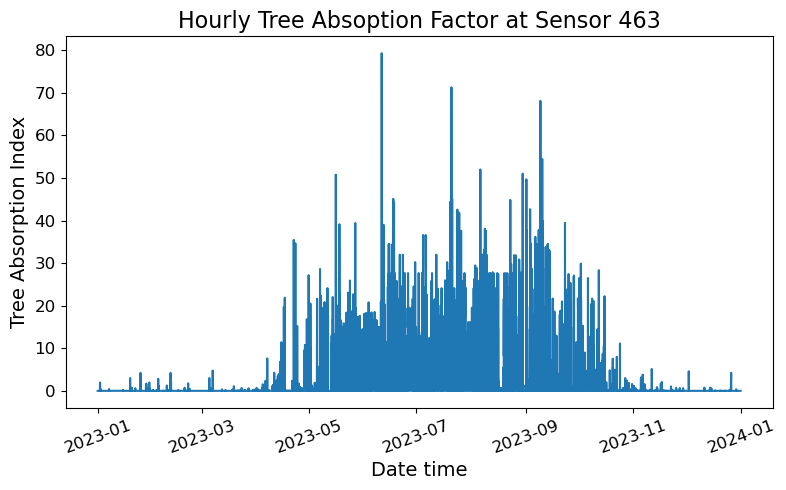

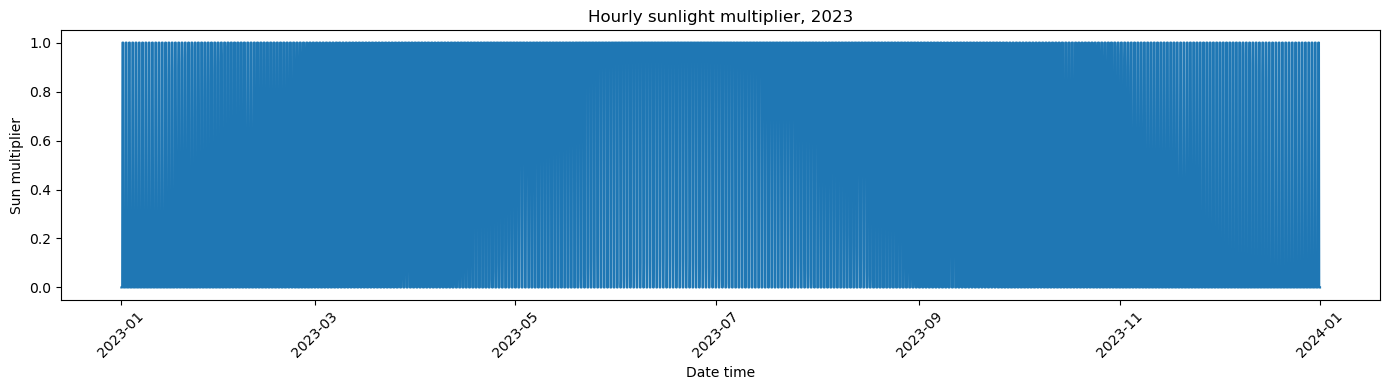

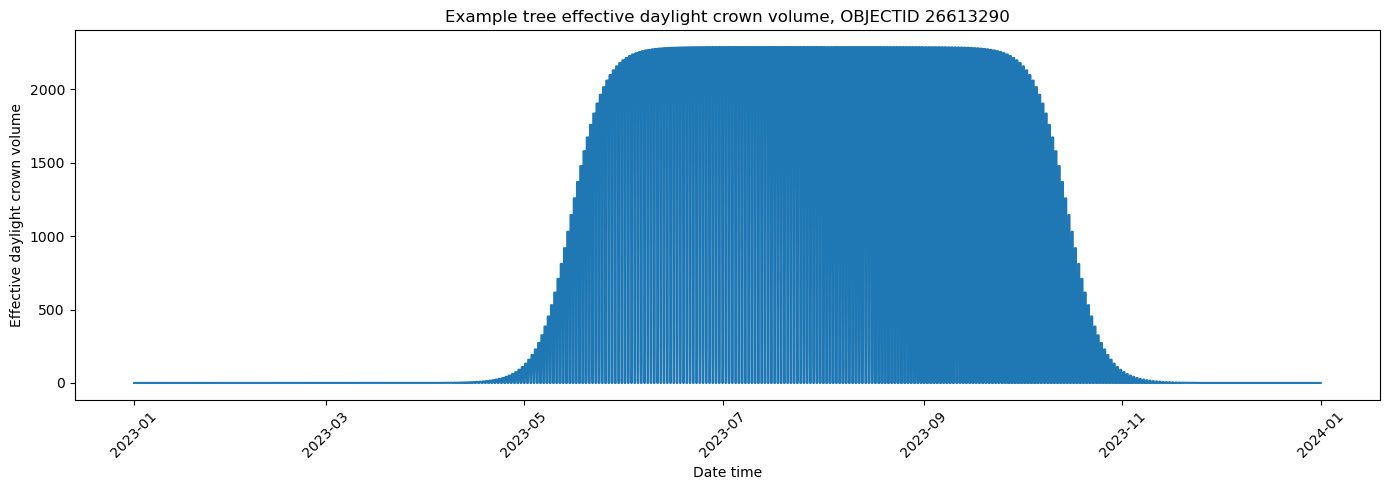

Example tree:
OBJECTID                  26613290
COMMON_NAME                    Ash
CROWN_AREA_COMPLETE     285.933967
CROWN_VOLUME           2287.471736
is_evergreen                 False
Name: 93, dtype: object


In [115]:
# ============================================================
# Quick checks: has the integration worked?
# ============================================================

import matplotlib.pyplot as plt

# 1) Night-time G_h should be zero because sun_multiplier = 0.
night_check = G_df.loc[G_df["sun_multiplier"] == 0, "G_h_effective"]
print("Night-time rows:", len(night_check))
print("Max night-time G_h:", night_check.max() if len(night_check) else "No night rows found")

# 2) Day-time G_h should contain positive values if nearby trees + wind geometry contribute.
day_check = G_df.loc[G_df["sun_multiplier"] > 0, "G_h_effective"]
print("Day-time rows:", len(day_check))
print("Max day-time G_h:", day_check.max() if len(day_check) else "No day rows found")

# 3) Plot annual hourly G_h for 2023.
plt.figure(figsize=(8, 5))
plt.plot(G_df["DATE_TIME_STR"], G_df["G_h_effective"])

# Added fontsize to title and axes labels
plt.title("Hourly Tree Absoption Factor at Sensor 463", fontsize=16)
plt.xlabel("Date time", fontsize=14)
plt.ylabel("Tree Absorption Index", fontsize=14)

# Added fontsize to the ticks so they match the larger labels
plt.xticks(rotation=20, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# 4) Plot sunlight multiplier to check sunrise/sunset behaviour.
plt.figure(figsize=(14, 4))
plt.plot(G_df["DATE_TIME_STR"], G_df["sun_multiplier"])
plt.title("Hourly sunlight multiplier, 2023")
plt.xlabel("Date time")
plt.ylabel("Sun multiplier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5) Example tree effective volume across 2023.
example_tree = nearby_trees.iloc[0].copy()

example_leaf = hourly_context_model["day_of_year"].apply(
    lambda doy: leaf_multiplier(
        day_of_year=doy,
        start_month=example_tree["leaf_start_month"],
        end_month=example_tree["leaf_end_month"],
        evergreen=example_tree["is_evergreen"]
    )
)

example_effective_volume = (
    example_tree["CROWN_VOLUME"] *
    example_leaf *
    hourly_context_model["sun_multiplier"]
)

plt.figure(figsize=(14, 5))
plt.plot(hourly_context_model["DATE_TIME_STR"], example_effective_volume)
plt.title(f"Example tree effective daylight crown volume, OBJECTID {example_tree['OBJECTID']}")
plt.xlabel("Date time")
plt.ylabel("Effective daylight crown volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Example tree:")
print(example_tree[["OBJECTID", "COMMON_NAME", "CROWN_AREA_COMPLETE", "CROWN_VOLUME", "is_evergreen"]])

In [103]:
print(G_df)

      SITE_ID   EASTING  NORTHING   NOX       DATE_TIME_STR       date  \
0         463  362926.0  175590.0   9.0 2023-01-01 01:00:00 2023-01-01   
1         463  362926.0  175590.0  12.0 2023-01-01 02:00:00 2023-01-01   
2         463  362926.0  175590.0   6.0 2023-01-01 03:00:00 2023-01-01   
3         463  362926.0  175590.0   7.0 2023-01-01 04:00:00 2023-01-01   
4         463  362926.0  175590.0   6.0 2023-01-01 05:00:00 2023-01-01   
...       ...       ...       ...   ...                 ...        ...   
8754      463  362926.0  175590.0  30.0 2023-12-31 19:00:00 2023-12-31   
8755      463  362926.0  175590.0  17.0 2023-12-31 20:00:00 2023-12-31   
8756      463  362926.0  175590.0  17.0 2023-12-31 21:00:00 2023-12-31   
8757      463  362926.0  175590.0  17.0 2023-12-31 22:00:00 2023-12-31   
8758      463  362926.0  175590.0  13.0 2023-12-31 23:00:00 2023-12-31   

      day_of_year  month  hour          sunrise_dt           sunset_dt  \
0               1      1     1 2023-0

In [104]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hourly_wakes(hour_index, model_df, tree_df, sensor_x, sensor_y):
    """
    Generates a wake/sink map for a single aligned sensor hour.

    Uses:
    - wind speed and direction from model_df
    - sun_multiplier from model_df
    - day_of_year from model_df
    - tree-specific leaf_multiplier inside the loop
    """

    # -----------------------------
    # 1. Extract aligned hourly data
    # -----------------------------

    row = model_df.iloc[hour_index]

    timestamp = row.DATE_TIME_STR
    U = row.mean_wind_speed
    direction = row.mean_wind_dir
    sun_multiplier = row.sun_multiplier
    day_of_year = row.day_of_year

    print(f"Generating map for hour index {hour_index}")
    print(f"Timestamp: {timestamp}")
    print(f"Wind speed: {U:.3f} m/s")
    print(f"Wind direction: {direction:.1f}°")
    print(f"Sun multiplier: {sun_multiplier:.3f}")
    print(f"Day of year: {day_of_year}")

    if pd.isna(U) or pd.isna(direction) or pd.isna(sun_multiplier):
        print("Missing wind or sunlight data for this hour. Cannot generate map.")
        return None, None

    # -----------------------------
    # 2. Setup spatial grid
    # -----------------------------

    resolution = 150

    x_range = np.linspace(sensor_x - 300, sensor_x + 300, resolution)
    y_range = np.linspace(sensor_y - 300, sensor_y + 300, resolution)

    X_grid, Y_grid = np.meshgrid(x_range, y_range)

    X_3d = X_grid[..., np.newaxis]
    Y_3d = Y_grid[..., np.newaxis]

    # -----------------------------
    # 3. Physics parameters
    # -----------------------------

    D = 0.2
    T_max = 900

    dt = 1.0 if U <= 1.0 else 1.0 / U
    dynamic_T_max = min(T_max, 400 / U) if U > 0.1 else T_max
    t_array = np.arange(dt, dynamic_T_max + dt, dt)

    # -----------------------------
    # 4. Wind vector convention
    # -----------------------------

    theta = np.radians(direction)

    u_wind = U * np.sin(theta)
    v_wind = U * np.cos(theta)

    G_map = np.zeros_like(X_grid, dtype=float)

    # -----------------------------
    # 5. Superposition over trees
    # -----------------------------

    trees_hour = tree_df.copy()

    effective_volumes = []
    effective_areas = []
    tree_leaf_multipliers = []

    for tree in trees_hour.itertuples():

        tree_leaf_multiplier = leaf_multiplier(
            day_of_year=day_of_year,
            start_month=tree.leaf_start_month,
            end_month=tree.leaf_end_month,
            evergreen=tree.is_evergreen
        )

        effective_area = tree.CROWN_AREA_COMPLETE * tree_leaf_multiplier
        effective_volume = tree.CROWN_VOLUME * tree_leaf_multiplier * sun_multiplier

        effective_areas.append(effective_area)
        effective_volumes.append(effective_volume)
        tree_leaf_multipliers.append(tree_leaf_multiplier)

        if effective_area <= 0 or effective_volume <= 0:
            continue

        radius = np.sqrt(effective_area / np.pi)
        sigma_0 = radius / 2.15

        puff_x = tree.X + (u_wind * t_array)
        puff_y = tree.Y + (v_wind * t_array)

        sigma_t = sigma_0 + (D * t_array)

        dist_sq = (X_3d - puff_x) ** 2 + (Y_3d - puff_y) ** 2

        coeff = (effective_volume * dt) / (2 * np.pi * sigma_t ** 2)
        exponent = np.exp(-dist_sq / (2 * sigma_t ** 2))

        G_map += np.sum(coeff * exponent, axis=2)

    trees_hour["leaf_multiplier"] = tree_leaf_multipliers
    trees_hour["effective_area"] = effective_areas
    trees_hour["effective_volume"] = effective_volumes

    # -----------------------------
    # 6. Plot results
    # -----------------------------

    plt.figure(figsize=(12, 10))

    contour = plt.contourf(
        X_grid,
        Y_grid,
        -G_map,
        levels=60,
        cmap="Greens_r"
    )

    cbar = plt.colorbar(contour)
    cbar.set_label(
        "Effective Geometric Sink Factor",
        rotation=270,
        labelpad=20
    )

    plt.scatter(
        trees_hour["X"],
        trees_hour["Y"],
        s=trees_hour["effective_area"] * 1.5,
        color="black",
        alpha=0.4,
        label="Trees scaled by effective crown area"
    )

    plt.plot(
        sensor_x,
        sensor_y,
        "ro",
        markersize=12,
        label="NOx Sensor",
        markeredgecolor="white"
    )

    arrow_len = 50

    plt.arrow(
        sensor_x - 150,
        sensor_y + 150,
        arrow_len * np.sin(theta),
        arrow_len * np.cos(theta),
        width=3,
        head_width=10,
        color="blue",
        label="Wind Direction"
    )

    plt.title(
        f"Effective Pollution Sink Map\n"
        f"{timestamp} | U={U:.2f} m/s | Dir={direction:.1f}° | Sun={sun_multiplier:.2f}"
    )

    plt.xlabel("East Coordinate (m)")
    plt.ylabel("North Coordinate (m)")
    plt.legend(loc="lower right")
    plt.axis("equal")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    return G_map, trees_hour

Generating map for hour index 4782
Timestamp: 2023-07-19 07:00:00
Wind speed: 5.000 m/s
Wind direction: 270.0°
Sun multiplier: 1.000
Day of year: 200


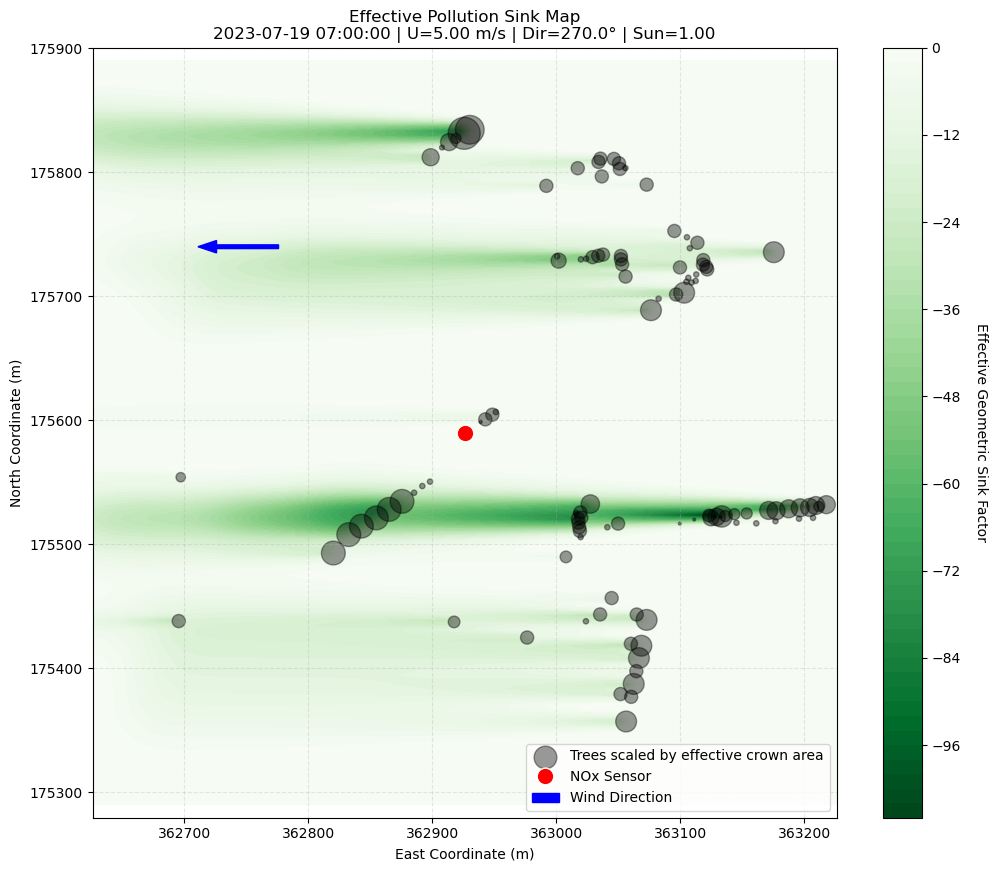

In [105]:
G_map, trees_hour = plot_hourly_wakes(
    hour_index=4782,
    model_df=G_df,
    tree_df=nearby_trees,
    sensor_x=SENSOR_X,
    sensor_y=SENSOR_Y
)

Generating map for hour index 6232
Timestamp: 2023-09-17 17:00:00
Wind speed: 5.000 m/s
Wind direction: 90.0°
Sun multiplier: 1.000
Day of year: 260


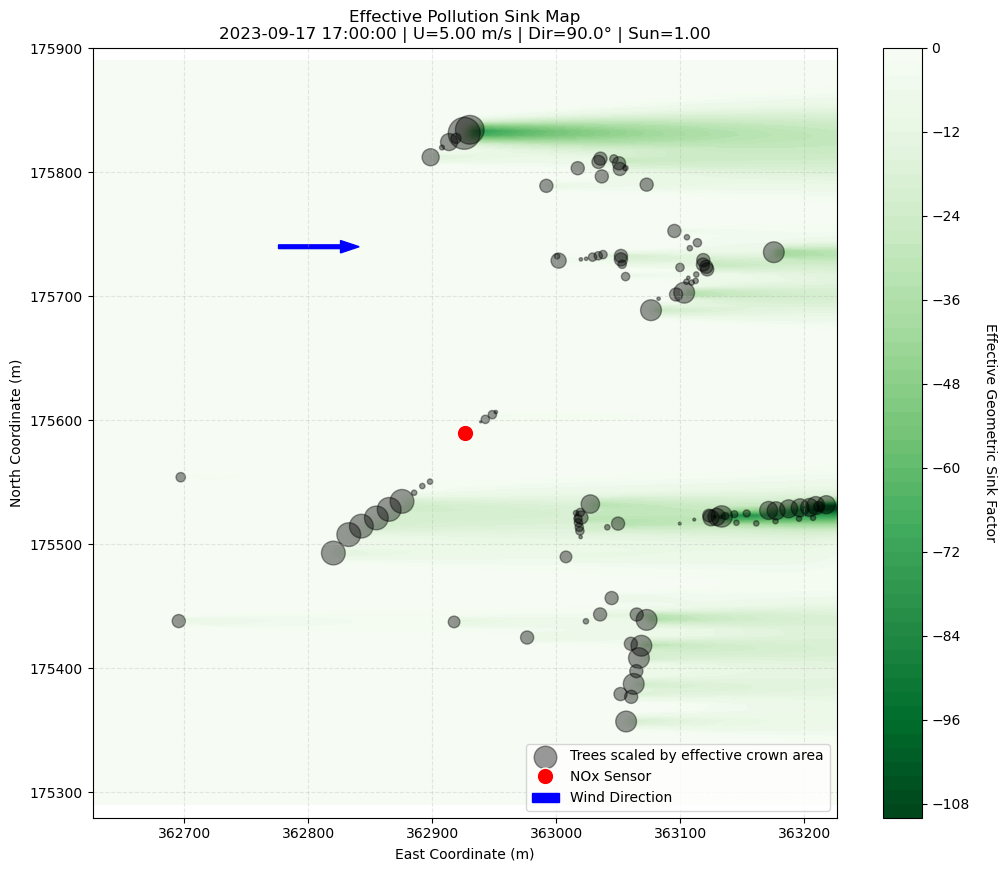

In [106]:
daylight_hours = G_df[
    (G_df["sun_multiplier"] > 0) &
    (G_df["mean_wind_speed"].notna()) &
    (G_df["mean_wind_dir"].notna())
]

test_hour = daylight_hours.index[3737]

G_map, trees_hour = plot_hourly_wakes(
    hour_index=test_hour,
    model_df=G_df,
    tree_df=nearby_trees,
    sensor_x=SENSOR_X,
    sensor_y=SENSOR_Y
)